In [3]:
%cd /home/dani2442/Projects/neuroscience

/home/dani2442/Projects/neuroscience


In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data = []
for i in range(5):
    data.append(np.load(f"data_processed/adhd/timeseries_{i}.npy"))

In [7]:
data[0].shape

(176, 39)

In [36]:
class TimeSeriesDataset(Dataset):
    """Dataset class for time series data with residual learning."""
    
    def __init__(self, data):
        """
        Args:
            data: numpy array of shape (n_t, n_x) where n_t is time steps, n_x is features
        """
        self.data = torch.FloatTensor(data)
        
    def __len__(self):
        return len(self.data) - 1  # We need pairs (x_t, x_{t+1})
    
    def __getitem__(self, idx):
        x_t = self.data[idx]
        x_t_plus_1 = self.data[idx + 1]
        return x_t, x_t_plus_1
    
class ResidualNN(nn.Module):
    """1-layer neural network for residual learning: x_{t+1} = x_t + f_θ(x_t)"""
    
    def __init__(self, input_dim, hidden_dim=20, activation='relu'):
        super(ResidualNN, self).__init__()
            
        # Single layer network f_θ(x_t)
        self.f_theta = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            #nn.Tanh(),
            #nn.Linear(hidden_dim, input_dim)  # Output same size as input for residual
        )
    
    def forward(self, x_t):
        # Residual connection: x_{t+1} = x_t + f_θ(x_t)
        residual = self.f_theta(x_t)
        x_t_plus_1 = x_t + residual
        return x_t_plus_1

In [37]:
class ResidualNNTrainer:
    """Trainer class for the residual neural network."""
    
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.train_losses = []
        self.val_losses = []
        
    def train(self, train_loader, val_loader=None, epochs=100, lr=0.001, 
              criterion=nn.MSELoss(), optimizer_class=optim.Adam):
        """
        Train the model.
        
        Args:
            train_loader: DataLoader for training data
            val_loader: DataLoader for validation data (optional)
            epochs: Number of training epochs
            lr: Learning rate
            criterion: Loss function
            optimizer_class: Optimizer class
        """
        optimizer = optimizer_class(self.model.parameters(), lr=lr)
        
        for epoch in range(epochs):
            # Training
            self.model.train()
            train_loss = 0.0
            
            for x_t, x_t_plus_1 in train_loader:
                x_t = x_t.to(self.device)
                x_t_plus_1 = x_t_plus_1.to(self.device)
                
                optimizer.zero_grad()
                pred_x_t_plus_1 = self.model(x_t)
                loss = criterion(pred_x_t_plus_1, x_t_plus_1)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            avg_train_loss = train_loss / len(train_loader)
            self.train_losses.append(avg_train_loss)
            
            # Validation
            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                
                with torch.no_grad():
                    for x_t, x_t_plus_1 in val_loader:
                        x_t = x_t.to(self.device)
                        x_t_plus_1 = x_t_plus_1.to(self.device)
                        
                        pred_x_t_plus_1 = self.model(x_t)
                        loss = criterion(pred_x_t_plus_1, x_t_plus_1)
                        val_loss += loss.item()
                
                avg_val_loss = val_loss / len(val_loader)
                self.val_losses.append(avg_val_loss)
                
                if (epoch + 1) % 10 == 0:
                    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
            else:
                if (epoch + 1) % 10 == 0:
                    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}')
    
    def predict(self, x_t):
        """Predict next state given current state."""
        self.model.eval()
        with torch.no_grad():
            if isinstance(x_t, np.ndarray):
                x_t = torch.FloatTensor(x_t).to(self.device)
            return self.model(x_t)
    
    def multi_step_prediction(self, x_0, n_steps):
        """Generate multi-step predictions starting from x_0."""
        self.model.eval()
        predictions = [x_0]
        x_current = x_0.clone() if isinstance(x_0, torch.Tensor) else torch.FloatTensor(x_0)
        x_current = x_current.to(self.device)
        
        with torch.no_grad():
            for _ in range(n_steps):
                x_next = self.model(x_current.unsqueeze(0) if x_current.dim() == 1 else x_current)
                if x_next.dim() > 1:
                    x_next = x_next.squeeze(0)
                predictions.append(x_next.cpu())
                x_current = x_next
                
        return torch.stack(predictions)
    
    def plot_losses(self):
        """Plot training and validation losses."""
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_losses, label='Training Loss')
        if self.val_losses:
            plt.plot(self.val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.show()

Training started...
Epoch [10/1000], Train Loss: 0.668576, Val Loss: 0.935112
Epoch [20/1000], Train Loss: 0.595298, Val Loss: 0.970897
Epoch [30/1000], Train Loss: 0.572321, Val Loss: 1.014723
Epoch [40/1000], Train Loss: 0.556420, Val Loss: 1.043919
Epoch [50/1000], Train Loss: 0.558867, Val Loss: 1.062650
Epoch [60/1000], Train Loss: 0.560537, Val Loss: 1.072042
Epoch [70/1000], Train Loss: 0.558483, Val Loss: 1.080456
Epoch [80/1000], Train Loss: 0.566553, Val Loss: 1.084212
Epoch [90/1000], Train Loss: 0.558523, Val Loss: 1.090868
Epoch [100/1000], Train Loss: 0.557342, Val Loss: 1.092026
Epoch [110/1000], Train Loss: 0.560472, Val Loss: 1.095629
Epoch [120/1000], Train Loss: 0.567682, Val Loss: 1.092233
Epoch [130/1000], Train Loss: 0.574020, Val Loss: 1.093854
Epoch [140/1000], Train Loss: 0.559237, Val Loss: 1.094911
Epoch [150/1000], Train Loss: 0.555029, Val Loss: 1.098092
Epoch [160/1000], Train Loss: 0.551025, Val Loss: 1.096183
Epoch [170/1000], Train Loss: 0.555464, Val L

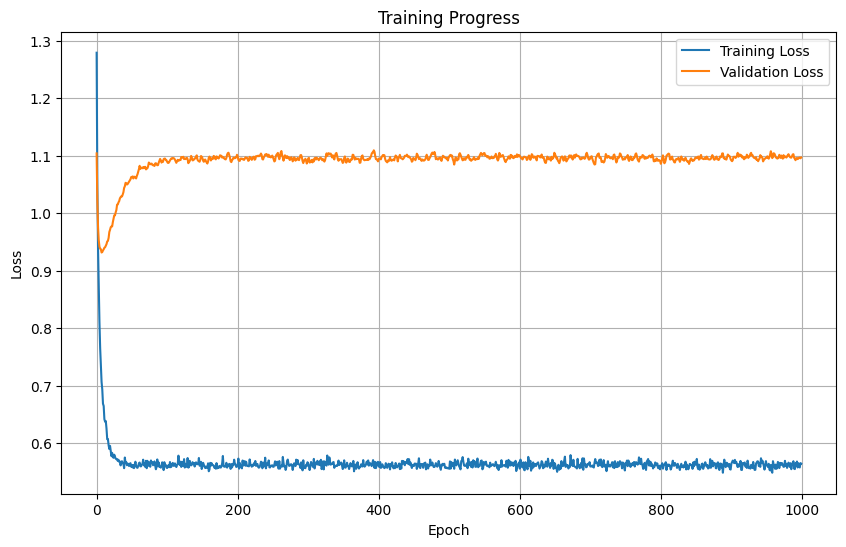

Input: tensor([-1.1503, -0.8954, -0.4659, -0.1060,  0.8791,  0.4317,  0.4063, -1.8700,
        -0.3873,  0.6163, -0.8509, -0.4326,  0.5201, -0.5282,  0.5184,  0.5902,
        -0.1812,  0.6599,  0.1574, -0.0608, -0.8304,  0.3473, -0.8482, -0.3483,
        -0.7224, -0.9604, -1.2767,  0.4173,  0.6400,  0.0773,  0.8926,  0.0384,
         0.0132,  0.1455, -0.8967, -0.5891, -0.0742,  0.2572,  0.2078])
Predicted next state: tensor([-0.5163, -0.4030,  0.1464, -0.2134,  0.4810, -0.2667,  0.7063, -0.2959,
        -0.6251,  0.7602,  0.6029,  0.4908,  0.1806, -0.1906,  0.7643,  0.8667,
         0.1008,  0.2837,  0.1018, -0.0549, -0.3078, -0.2852, -0.6626, -0.4166,
        -0.0675, -0.4394, -0.8121,  0.1778,  0.2429, -0.2406, -0.1609,  0.5556,
        -0.2907, -0.1810,  0.0369, -0.4639,  0.0357, -0.2016, -0.0560])
Actual next state: [ 0.68328811 -0.1766352  -0.02726714 -0.24694209  0.12736072  1.93091851
 -0.16243388 -2.73744257 -0.02945325 -0.68855334 -1.64578191 -1.01843422
  0.936991   -1.047438

In [38]:
n_t, n_x = data[0].shape
train_data = data[0]
val_data = data[1]

# Create datasets and dataloaders
train_dataset = TimeSeriesDataset(train_data)
val_dataset = TimeSeriesDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize model and trainer
model = ResidualNN(input_dim=n_x, hidden_dim=4,)
device = 'cpu' #'cuda' if torch.cuda.is_available() else 'cpu'
trainer = ResidualNNTrainer(model, device=device)

# Train the model
print("Training started...")
trainer.train(train_loader, val_loader, epochs=1000, lr=1e-2)

# Plot training progress
trainer.plot_losses()

# Example prediction
x_test = torch.FloatTensor(val_data[0])
x_pred = trainer.predict(x_test)
print(f"Input: {x_test}")
print(f"Predicted next state: {x_pred}")
print(f"Actual next state: {val_data[1]}")

# Multi-step prediction
multi_pred = trainer.multi_step_prediction(x_test, n_steps=10)
print(f"Multi-step predictions shape: {multi_pred.shape}")